In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv("../Data/coral_regime.csv")
print("Original shape:", df.shape)
print(df.head())

Original shape: (41361, 62)
   Site_ID  Sample_ID Data_Source  Latitude_Degrees  Longitude_Degrees  \
0     2501   10324336      Donner            23.163           -82.5260   
1     3467   10324754      Donner           -17.575          -149.7833   
2     1794   10323866      Donner            18.369           -64.5640   
3     8647   10328028      Donner            17.760           -64.5680   
4     8648   10328029      Donner            17.769           -64.5830   

  Ocean_Name Reef_ID            Realm_Name  \
0   Atlantic      nd     Tropical Atlantic   
1    Pacific      nd  Eastern Indo-Pacific   
2   Atlantic      nd     Tropical Atlantic   
3   Atlantic      nd     Tropical Atlantic   
4   Atlantic      nd     Tropical Atlantic   

                               Ecoregion_Name      Country_Name  ...  \
0                     Cuba and Cayman Islands              Cuba  ...   
1            Society Islands French Polynesia  French Polynesia  ...   
2  Hispaniola Puerto Rico and Less

C:\Windows\Temp\ipykernel_31312\929683737.py:1: DtypeWarning: Columns (13,15,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../Data/coral_regime.csv")


In [15]:
df = df.replace('nd', pd.NA)
numeric_cols = [
    'Latitude_Degrees','Longitude_Degrees','Depth_m','Percent_Cover',
    'Bleaching_Level','Percent_Bleaching','ClimSST','Temperature_Kelvin',
    'Temperature_Mean','Temperature_Minimum','Temperature_Maximum',
    'Temperature_Kelvin_Standard_Deviation','Windspeed','SSTA','SSTA_Mean',
    'SSTA_Maximum','SSTA_Minimum','TSA','TSA_Mean','TSA_Maximum','TSA_Minimum'
]
df = df[[c for c in numeric_cols if c in df.columns]]
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=['Percent_Bleaching', 'Percent_Cover'])
df = df.fillna(df.mean(numeric_only=True))

print("Cleaned shape:", df.shape)
print(df.describe())


Cleaned shape: (22673, 21)
       Latitude_Degrees  Longitude_Degrees       Depth_m  Percent_Cover  \
count      22673.000000       22673.000000  22673.000000   22673.000000   
mean           3.829787          61.875749      6.505346      19.674158   
std           15.211652          96.899350      3.402489      21.020409   
min          -28.864500        -179.859400      0.100000       0.000000   
25%           -8.684900         -32.445100      4.000000       1.250000   
50%            5.777100         104.510600      6.000000      12.500000   
75%           15.978100         123.520000     10.000000      33.120000   
max           34.098100         179.964500     23.000000      98.750000   

       Bleaching_Level  Percent_Bleaching       ClimSST  Temperature_Kelvin  \
count              0.0       22673.000000  22673.000000        22673.000000   
mean               NaN           3.048284    294.729750          301.262068   
std                NaN          10.788754     14.370848     

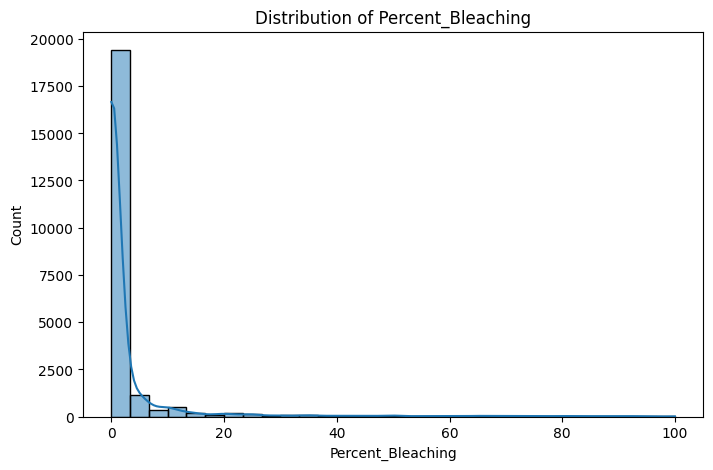

In [16]:
#Distribution of Percent_Bleaching
plt.figure(figsize=(8,5))
sns.histplot(df['Percent_Bleaching'], kde=True, bins=30)
plt.title("Distribution of Percent_Bleaching")
plt.show()


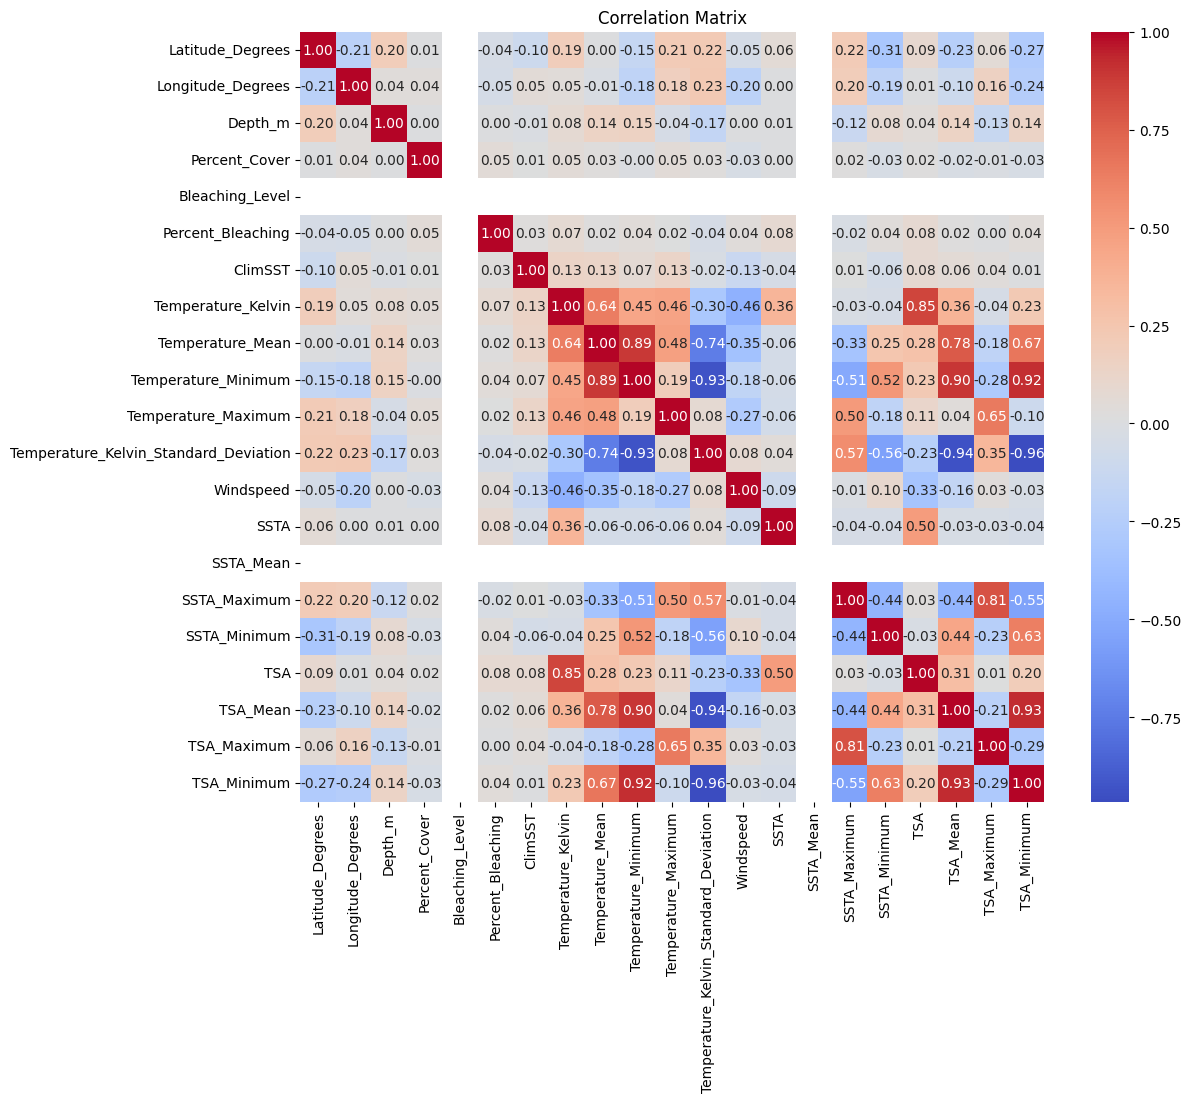

In [17]:
# Correlation Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

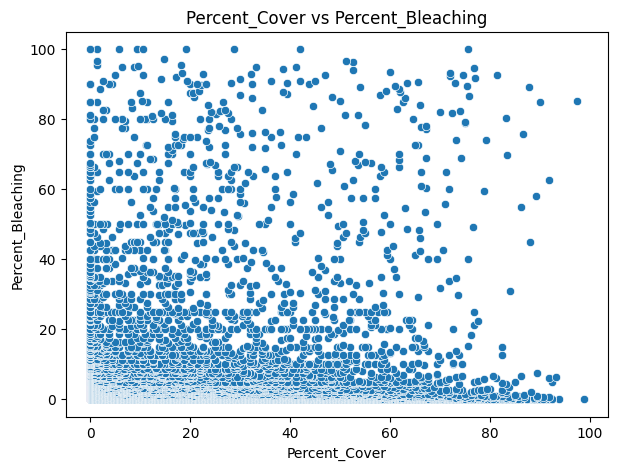

In [18]:
# Scatter: Percent_Cover vs Percent_Bleaching
plt.figure(figsize=(7,5))
sns.scatterplot(x='Percent_Cover', y='Percent_Bleaching', data=df)
plt.title("Percent_Cover vs Percent_Bleaching")
plt.show()